# Introduction to Deep Learning, Assignment 2, Task 2

# Introduction


The goal of this assignment is to learn how to use encoder-decoder recurrent neural networks (RNNs). Specifically we will be dealing with a sequence to sequence problem and try to build recurrent models that can learn the principles behind simple arithmetic operations (**integer addition, subtraction and multiplication.**).

<img src="https://i.ibb.co/5Ky5pbk/Screenshot-2023-11-10-at-07-51-21.png" alt="Screenshot-2023-11-10-at-07-51-21" border="0" width="500"></a>

In this assignment you will be working with three different kinds of models, based on input/output data modalities:
1. **Text-to-text**: given a text query containing two integers and an operand between them (+ or -) the model's output should be a sequence of integers that match the actual arithmetic result of this operation
2. **Image-to-text**: same as above, except the query is specified as a sequence of images containing individual digits and an operand.
3. **Text-to-image**: the query is specified in text format as in the text-to-text model, however the model's output should be a sequence of images corresponding to the correct result.


### Description
Let us suppose that we want to develop a neural network that learns how to add or subtract
two integers that are at most two digits long. For example, given input strings of 5 characters: ‘81+24’ or
’41-89’ that consist of 2 two-digit long integers and an operand between them, the network should return a
sequence of 3 characters: ‘105 ’ or ’-48 ’ that represent the result of their respective queries. Additionally,
we want to build a model that generalizes well - if the network can extract the underlying principles behind
the ’+’ and ’-’ operands and associated operations, it should not need too many training examples to generate
valid answers to unseen queries. To represent such queries we need 13 unique characters: 10 for digits (0-9),
2 for the ’+’ and ’-’ operands and one for whitespaces ’ ’ used as padding.
The example above describes a text-to-text sequence mapping scenario. However, we can also use different
modalities of data to represent our queries or answers. For that purpose, the MNIST handwritten digit
dataset is going to be used again, however in a slightly different format. The functions below will be used to create our datasets.

---

*To work on this notebook you should create a copy of it.*

When using the Lab Computers, download the Jupyter Notebook to one of the machines first.

If you want to use Google Colab, you should first copy this notebook and enable GPU runtime in 'Runtime -> Change runtime type -> Hardware acceleration -> GPU **OR** TPU'.


# Function definitions for creating the datasets

First we need to create our datasets that are going to be used for training our models.

In order to create image queries of simple arithmetic operations such as '15+13' or '42-10' we need to create images of '+' and '-' signs using ***open-cv*** library. We will use these operand signs together with the MNIST dataset to represent the digits.

In [110]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split

from keras.layers import Dense, RNN, LSTM, Flatten, TimeDistributed, LSTMCell
from keras.layers import RepeatVector, Conv2D, SimpleRNN, GRU, Reshape, ConvLSTM2D, Conv2DTranspose

In [111]:
#check gpu availability
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


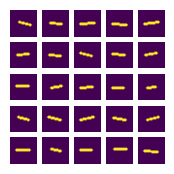

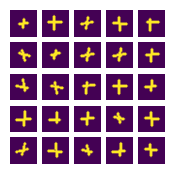

In [112]:
from scipy.ndimage import rotate


# Create plus/minus operand signs
def generate_images(number_of_images=50, sign='-'):
    blank_images = np.zeros([number_of_images, 28, 28])  # Dimensionality matches the size of MNIST images (28x28)
    x = np.random.randint(12, 16, (number_of_images, 2)) # Randomized x coordinates
    y1 = np.random.randint(6, 10, number_of_images)       # Randomized y coordinates
    y2 = np.random.randint(18, 22, number_of_images)     # -||-

    for i in range(number_of_images): # Generate n different images
        cv2.line(blank_images[i], (y1[i], x[i,0]), (y2[i], x[i, 1]), (255,0,0), 2, cv2.LINE_AA)     # Draw lines with randomized coordinates
        if sign == '+':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA) # Draw lines with randomized coordinates

    return blank_images

def show_generated(images, n=5):
    plt.figure(figsize=(2, 2))
    for i in range(n**2):
        plt.subplot(n, n, i+1)
        plt.axis('off')
        plt.imshow(images[i])
    plt.show()

show_generated(generate_images())
show_generated(generate_images(sign='+'))

In [113]:
def create_data(highest_integer, num_addends=2, operands=['+', '-']):
    """
    Creates the following data for all pairs of integers up to [1:highest integer][+/-][1:highest_integer]:

    @return:
    X_text: '51+21' -> text query of an arithmetic operation (5)
    X_img : Stack of MNIST images corresponding to the query (5 x 28 x 28) -> sequence of 5 images of size 28x28
    y_text: '72' -> answer of the arithmetic text query
    y_img :  Stack of MNIST images corresponding to the answer (3 x 28 x 28)

    Images for digits are picked randomly from the whole MNIST dataset.
    """

    num_indices = [np.where(MNIST_labels==x) for x in range(10)]
    num_data = [MNIST_data[inds] for inds in num_indices]
    image_mapping = dict(zip(unique_characters[:10], num_data))
    image_mapping['-'] = generate_images()
    image_mapping['+'] = generate_images(sign='+')
    image_mapping['*'] = generate_images(sign='*')
    image_mapping[' '] = np.zeros([1, 28, 28])

    X_text, X_img, y_text, y_img = [], [], [], []

    for i in range(highest_integer + 1):      # First addend
        for j in range(highest_integer + 1):  # Second addend
            for sign in operands: # Create all possible combinations of operands
                query_string = to_padded_chars(str(i) + sign + str(j), max_len=max_query_length, pad_right=True)
                query_image = []
                for n, char in enumerate(query_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    query_image.append(image_set[index].squeeze())

                result = eval(query_string)
                result_string = to_padded_chars(result, max_len=max_answer_length, pad_right=True)
                result_image = []
                for n, char in enumerate(result_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    result_image.append(image_set[index].squeeze())

                X_text.append(query_string)
                X_img.append(np.stack(query_image))
                y_text.append(result_string)
                y_img.append(np.stack(result_image))

    return np.stack(X_text), np.stack(X_img)/255., np.stack(y_text), np.stack(y_img)/255.

def to_padded_chars(integer, max_len=3, pad_right=False):
    """
    Returns a string of len()=max_len, containing the integer padded with ' ' on either right or left side
    """
    length = len(str(integer))
    padding = (max_len - length) * ' '
    if pad_right:
        return str(integer) + padding
    else:
        return padding + str(integer)


# Creating our data

The dataset consists of 20000 samples that (additions and subtractions between all 2-digit integers) and they have two kinds of inputs and label modalities:

  **X_text**: strings containing queries of length 5: ['  1+1  ', '11-18', ...]

  **X_image**: a stack of images representing a single query, dimensions: [5, 28, 28]

  **y_text**: strings containing answers of length 3: ['  2', '156']

  **y_image**: a stack of images that represents the answer to a query, dimensions: [3, 28, 28]

(20000,) (20000, 5, 28, 28) (20000,) (20000, 3, 28, 28)
Query #2819

X_text: "14-9 " = y_text: "5  "


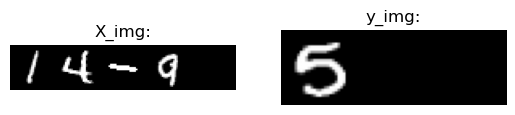

Query #3450

X_text: "17+25" = y_text: "42 "


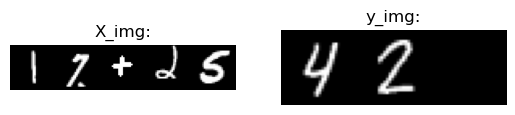

Query #3091

X_text: "15-45" = y_text: "-30"


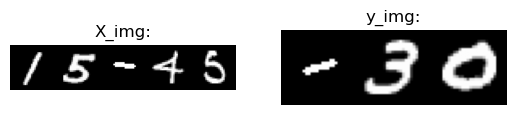

Query #3474

X_text: "17+37" = y_text: "54 "


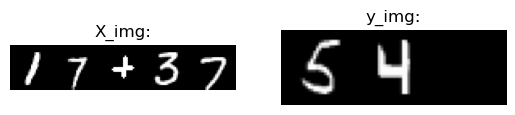

Query #4955

X_text: "24-77" = y_text: "-53"


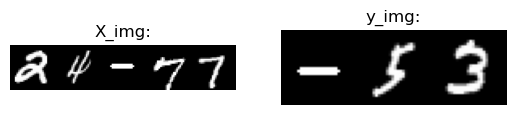

Query #4032

X_text: "20+16" = y_text: "36 "


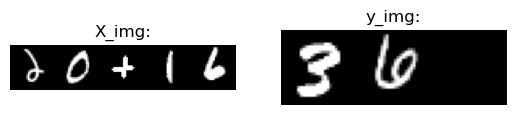

Query #8509

X_text: "42-54" = y_text: "-12"


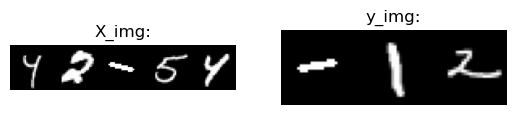

Query #4994

X_text: "24+97" = y_text: "121"


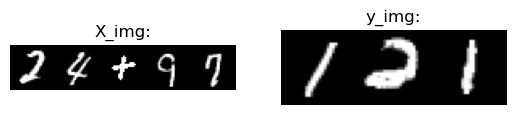

Query #4906

X_text: "24+53" = y_text: "77 "


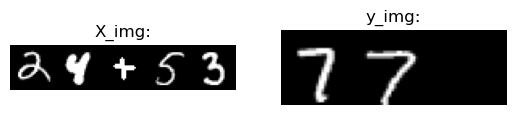

Query #1273

X_text: "6-36 " = y_text: "-30"


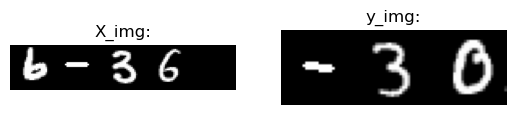

In [114]:
# Illustrate the generated query/answer pairs

unique_characters = '0123456789+- '       # All unique characters that are used in the queries (13 in total: digits 0-9, 2 operands [+, -], and a space character ' '.)
highest_integer = 99                      # Highest value of integers contained in the queries

max_int_length = len(str(highest_integer))# Maximum number of characters in an integer
max_query_length = max_int_length * 2 + 1 # Maximum length of the query string (consists of two integers and an operand [e.g. '22+10'])
max_answer_length = 3    # Maximum length of the answer string (the longest resulting query string is ' 1-99'='-98')

# Create the data (might take around a minute)
(MNIST_data, MNIST_labels), _ = tf.keras.datasets.mnist.load_data()
X_text, X_img, y_text, y_img = create_data(highest_integer)
print(X_text.shape, X_img.shape, y_text.shape, y_img.shape)


## Display the samples that were created
def display_sample(n):
    labels = ['X_img:', 'y_img:']
    for i, data in enumerate([X_img, y_img]):
        plt.subplot(1,2,i+1)
        # plt.set_figheight(15)
        plt.axis('off')
        plt.title(labels[i])
        plt.imshow(np.hstack(data[n]), cmap='gray')
    print('='*50, f'\nQuery #{n}\n\nX_text: "{X_text[n]}" = y_text: "{y_text[n]}"')
    plt.show()

for _ in range(10):
    display_sample(np.random.randint(0, 10000, 1)[0])

## Helper functions

The functions below will help with input/output of the data.

In [115]:
# One-hot encoding/decoding the text queries/answers so that they can be processed using RNNs
# You should use these functions to convert your strings and read out the output of your networks

def encode_labels(labels, max_len=3):
  n = len(labels)
  length = len(labels[0])
  char_map = dict(zip(unique_characters, range(len(unique_characters))))
  one_hot = np.zeros([n, length, len(unique_characters)])
  for i, label in enumerate(labels):
      m = np.zeros([length, len(unique_characters)])
      for j, char in enumerate(label):
          m[j, char_map[char]] = 1
      one_hot[i] = m

  return one_hot


def decode_labels(labels):
    pred = np.argmax(labels, axis=2)
    predicted = [''.join([unique_characters[i] for i in j]) for j in pred]

    return predicted

X_text_onehot = encode_labels(X_text)
y_text_onehot = encode_labels(y_text)

print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 5, 13) (20000, 3, 13)


---
---

## I. Text-to-text RNN model

The following code showcases how Recurrent Neural Networks (RNNs) are built using Keras. Several new layers are going to be used:

1. LSTM
2. TimeDistributed
3. RepeatVector

The code cell below explains each of these new components.

<img src="https://i.ibb.co/NY7FFTc/Screenshot-2023-11-10-at-09-27-25.png" alt="Screenshot-2023-11-10-at-09-27-25" border="0" width="500"></a>


In [116]:
def build_text2text_model():

    # We start by initializing a sequential model
    text2text = tf.keras.Sequential()

    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    text2text.add(LSTM(256, input_shape=(None, len(unique_characters))))

    # As the decoder RNN's input, repeatedly provide with the last output of RNN for each time step. Repeat 3 times as that's the maximum length of the output (e.g. '  1-99' = '-98')
    # when using 2-digit integers in queries. In other words, the RNN will always produce 3 characters as its output.
    text2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    text2text.add(LSTM(256, return_sequences=True))

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    text2text.summary()

    return text2text

n the text-to-text scenario, we are not interested in “memorizing” the whole addition/subtraction
table (about 20,000 strings in total); instead, we want the network to learn some general principles
behind these arithmetic operations. Therefore you should try multiple different splits for your training
and test sets (50% train - 50% test; 25% train - 75% test, 10% train, 90% test etc.) and evaluate the
accuracy and generalization capability of your models. Compare the outputs of your trained networks
to the true labels, and find out what kind of mistakes your models make on the misclassified samples.
Visualize these differences and try to explain them

In [117]:
# ## Your code (look at the assignment description for your tasks for text-to-text model):
# ## Your first task is to fit the text2text model using X_text and y_text)
# splits = [0.50, 0.25, 0.10]
# results = {}
# for i in range(len(splits)):
#     X_train, X_test, y_train, y_test = train_test_split(X_text_onehot, y_text_onehot, test_size=splits[i], random_state=42)
#     print(X_train.shape)
#     model = build_text2text_model()
#     model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test))
#     print(f"Train size: {X_train.shape[0]}")
#     results[splits[i]]= model.evaluate(X_test, y_test)
#     model.save(f'text2text_model_split_{splits[i]}.keras')


In [118]:
# #write results to file
# with open('text2text_results.txt', 'w') as f:
#     for split, result in results.items():
#         f.write(f'Split: {split}, Test Loss: {result[0]}, Test Accuracy: {result[1]}\n')

Compare the outputs of your trained networks
to the true labels, and find out what kind of mistakes your models make on the misclassified samples.
Visualize these differences and try to explain them

In [119]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
splits = [0.50, 0.25, 0.10]

for split in splits:
    model = tf.keras.models.load_model(f'text2text_model_split_{split}.keras')
    X_text_onehot_train, X_text_onehot_test, \
    y_text_onehot_train, y_text_onehot_test, \
    X_img_train, X_img_test = train_test_split(
        X_text_onehot,
        y_text_onehot,
        X_img,
        test_size=split,
        random_state=42
    )

    y_pred = model.predict(X_text_onehot_test)
    y_pred_decoded = decode_labels(y_pred)
    y_test_decoded = decode_labels(y_text_onehot_test)

    misclassified_indices = [i for i in range(len(y_test_decoded)) if y_test_decoded[i] != y_pred_decoded[i]]

    print(f'--- Misclassified samples for {split} split ---')
    mistakes = []
    # Show first 5 misclassified samples
    for idx in misclassified_indices:


        query_str = decode_labels(X_text_onehot_test[idx:idx+1])[0]

        query_images = X_img_test[idx]

        # print(f'Input: "{query_str}", True: "{y_test_decoded[idx]}", Predicted: "{y_pred_decoded[idx]}"')
        mistakes.append((y_test_decoded[idx], y_pred_decoded[idx]))

        # plt.figure(figsize=(4,2))
        # plt.axis('off')
        # plt.title(f'Actual Query Images for "{query_str}"')
        # plt.imshow(np.hstack(query_images), cmap='gray')
        # plt.show()
    #classify multiple types of mistakes:
    # type1:n -n = -,
    # type2: n - m = p where p-(n-m) = 1 or 10 or 100
    #type 3: n + m = p where p-(n+m) != 1 or 10 or 100
    mistakes_count = {'type1':0, 'type2':0, 'type3':0}
    for mistake in mistakes:
        true_answer, predicted_answer = mistake
        true_answer = true_answer.strip()
        predicted_answer = predicted_answer.strip()
        if predicted_answer == '-':
            mistakes_count['type1'] += 1
        elif abs(int(predicted_answer)-int(true_answer)) in [1,10,100]:
            mistakes_count['type2'] += 1
        else:
            mistakes_count['type3'] += 1
            print(predicted_answer, true_answer)

    print(f'Mistake types for split {split}: {mistakes_count}, total mistakes: {len(misclassified_indices)}')
    print(mistakes)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- Misclassified samples for 0.5 split ---
50 59
-1 -9
1 8
5 7
-1 -9
987 98
-1 -8
-90 -9
1 10
-1 -3
-44 -55
-7 -9
90 10
2 0
1 17
1 8
1 9
-99 -90
90 99
-1 -9
1 8
77 86
-1 -8
-1 -10
90 9
01 -1
-1 -8
1 9
-1 -3
01 -1
900 100
1 4
37 28
1 7
-1 -9
01 -1
-1 -3
10 99
1 9
900 100
-1 -9
900 100
900 100
-1 -8
-1 -3
-1 -3
3 1
900 100
-1 -9
4 6
900 100
1 -1
40 49
-1 -8
29 1
-1 -9
1 7
-1 -3
1 9
-1 -9
-1 -3
-1 -9
90 99
1 9
2 4
-1 -3
8 10
1 8
-1 -9
1 9
-1 -9
-1 -9
1 18
1 8
90 10
1 5
Mistake types for split 0.5: {'type1': 11, 'type2': 809, 'type3': 76}, total mistakes: 896
[('16 ', '17 '), ('0  ', '-1 '), ('0  ', '-  '), ('49 ', '59 '), ('0  ', '01 '), ('139', '149'), ('80 ', '70 '), ('156', '157'), ('49 ', '59 '), ('69 ', '79 '), ('59 ', '50 '), ('9  ', '8  '), ('-87', '-86'), ('40 ', '30 '), ('38 ', '48 '), ('-23', '-33'), ('0  ', '-  '), ('-19', '-18'), ('96 ', '97 '), ('-79', '-78'), ('-8 ', '-7 '), ('-45', '-44'), ('21 ', '20 '), ('76 ', '77 '), ('6  ', '7 


---
---

## II. Image to text RNN Model

Hint: There are two ways of building the encoder for such a model - again by using the regular LSTM cells (with flattened images as input vectors) or recurrect convolutional layers [ConvLSTM2D](https://keras.io/api/layers/recurrent_layers/conv_lstm2d/).

The goal here is to use **X_img** as inputs and **y_text** as outputs.

In [120]:
## Your code


---
---

## III. Text to image RNN Model

Hint: to make this model work really well you could use deconvolutional layers in your decoder (you might need to look up ***Conv2DTranspose*** layer). However, regular vector-based decoder will work as well.

The goal here is to use **X_text** as inputs and **y_img** as outputs.

version 1

In [ ]:

from tensorflow.keras import layers
def build_text2image_model():

    image_generator = tf.keras.Sequential([
        # This model will be fed the (256,) vector from the LSTM
        layers.InputLayer(input_shape=(256,)),

        layers.Dense(7 * 7 * 128, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 128)),

        layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid')
    ], name="image_generator")

    text2image = tf.keras.Sequential()

    text2image.add(LSTM(256, input_shape=(None, len(unique_characters)),dropout=0.05, recurrent_dropout= 0.05))

    text2image.add(layers.RepeatVector(3))

    text2image.add(LSTM(256, return_sequences=True,
                        dropout=0.05, recurrent_dropout=0.05))

    text2image.add(TimeDistributed(image_generator))

    text2image.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))
    text2image.summary()
    return text2image


version 2 (whoopsie the assigment was rnn and i am doing gan)

In [122]:

# from tensorflow.keras import layers
# def build_text2image_model():

#     image_generator = tf.keras.Sequential([
#         # This model will be fed the (256,) vector from the LSTM
#         layers.InputLayer(input_shape=(256,)),

#         layers.Dense(7 * 7 * 128, use_bias=False),
#         layers.BatchNormalization(),
#         layers.LeakyReLU(),

#         layers.Reshape((7, 7, 128)),

#         layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', use_bias=False),
#         layers.BatchNormalization(),
#         layers.LeakyReLU(),

#         layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same', use_bias=False),
#         layers.BatchNormalization(),
#         layers.LeakyReLU(),

#         layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid')
#     ], name="image_generator")

#     text2image = tf.keras.Sequential()

#     text2image.add(LSTM(256, input_shape=(None, len(unique_characters))))

#     text2image.add(layers.RepeatVector(3))

#     text2image.add(LSTM(256, return_sequences=True,))

#     text2image.add(TimeDistributed(image_generator))

#     text2image.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))
#     text2image.summary()
#     return text2image

# import tensorflow as tf
# from tensorflow.keras.layers import (
#     Input, Conv2D, MaxPooling2D, Flatten, Dense,
#     LSTM, TimeDistributed, InputLayer, LeakyReLU, Dropout
# )
# from tensorflow.keras.models import Model, Sequential

# def build_discriminator_GAN():
#     cnn_extractor = Sequential([
#         InputLayer(shape=(28, 28, 1)),
#         Conv2D(32, (3, 3), strides=2, padding='same'),
#         LeakyReLU(alpha=0.2),
#         Dropout(0.3),

#         Conv2D(64, (3, 3), strides=2, padding='same'),
#         LeakyReLU(alpha=0.2),
#         Dropout(0.3),

#         Flatten()
#     ], name="discriminator_cnn")


#     model = Sequential([
#         InputLayer(shape=(3, 28, 28, 1)),
#         TimeDistributed(cnn_extractor),
#         LSTM(64),
#         Dense(1)
#     ], name="Discriminator")

#     return model

In [123]:

# generator = build_text2image_model()

# discriminator = build_discriminator_GAN()


# generator_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
# discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.5)
# cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)


# @tf.function
# def train_step(text_batch, real_image_batch):

#     fake_images = generator(text_batch, training=True)

#     #train discriminator
#     with tf.GradientTape() as disc_tape:

#         real_output = discriminator(real_image_batch, training=True)

#         fake_output = discriminator(fake_images, training=True)

#         real_loss = cross_entropy(tf.random.uniform(shape=tf.shape(real_output), minval=0.7, maxval=0.9),
#                                 real_output)

#         fake_loss = cross_entropy(tf.random.uniform(shape=tf.shape(fake_output), minval=0.1, maxval=0.3),fake_output)

#         disc_loss = real_loss + fake_loss

#     discriminator_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
#     discriminator_optimizer.apply_gradients(zip(discriminator_grads, discriminator.trainable_variables))

#     #train g (twicde)
#     for _ in range(2):
#         with tf.GradientTape() as gen_tape:
#             # Generate new fake images
#             fake_images = generator(text_batch, training=True)
#             # Get prediction on these new fake images
#             fake_output = discriminator(fake_images, training=True)

#             gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)

#     # Calculate gradients for G
#     generator_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
#     generator_optimizer.apply_gradients(zip(generator_grads, generator.trainable_variables))


#     return gen_loss, disc_loss

In [124]:

# BATCH_SIZE = 64
# BUFFER_SIZE = len(X_text_onehot_train)

# X_text_onehot_train = X_text_onehot_train.astype('float32')
# X_img_train = X_img_train.astype('float32')
# X_img_train = X_img_train / 255.0

# train_dataset = tf.data.Dataset.from_tensor_slices(
#     (X_text_onehot_train, X_img_train)
# )
# train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# EPOCHS = 50
# import time

# for epoch in range(EPOCHS):
#     start_time = time.time()

#     # Track losses
#     epoch_gen_loss = []
#     epoch_disc_loss = []

#     # Iterate over each batch in the dataset
#     for batch_num, (text_batch, real_image_batch) in enumerate(train_dataset):

#         # Run one step of training
#         gen_loss, disc_loss = train_step(text_batch, real_image_batch)

#         epoch_gen_loss.append(gen_loss.numpy())
#         epoch_disc_loss.append(disc_loss.numpy())

#     # After the epoch, print progress
#     avg_gen_loss = tf.reduce_mean(epoch_gen_loss)
#     avg_disc_loss = tf.reduce_mean(epoch_disc_loss)

#     print(f"Epoch {epoch + 1}/{EPOCHS} --- Time: {time.time() - start_time:.2f}s")
#     print(f"  Generator Loss: {avg_gen_loss:.4f}, Discriminator Loss: {avg_disc_loss:.4f}")

# generator.save('text2image_gan.keras')

actual v2

In [ ]:
from tensorflow.keras import layers, losses
def bce_ssim_loss(y_true, y_pred):
    y_true_reshaped = tf.reshape(y_true, [-1, 28, 28, 1])
    y_pred_reshaped = tf.reshape(y_pred, [-1, 28, 28, 1])
    #binary_crossentropy
    mse = losses.mse(y_true_reshaped, y_pred_reshaped)


    mse_loss_flat = tf.reduce_mean(mse, axis=[1, 2])
    # SSIM (structural loss)

    ssim_scores = tf.image.ssim(y_true_reshaped, y_pred_reshaped, max_val=1.0)
    ssim_loss_flat = (1.0 - ssim_scores) / 2.0

    # Combine the losses
    mse_weight = 0.8
    ssim_weight = 0.2

    combined_loss = (mse_weight * mse_loss_flat) + (ssim_weight * ssim_loss_flat)
    return combined_loss

#seperate variant for monitoring both losses.
def ssim_metric(y_true, y_pred):

    y_true_reshaped = tf.reshape(y_true, [-1, 28, 28, 1])
    y_pred_reshaped = tf.reshape(y_pred, [-1, 28, 28, 1])

    ssim_scores = tf.image.ssim(y_true_reshaped, y_pred_reshaped, max_val=2.0)


    return tf.reduce_mean(ssim_scores)


# def mse_metric(y_true, y_pred):

#     y_true_reshaped = tf.reshape(y_true, [-1, 28, 28, 1])
#     y_pred_reshaped = tf.reshape(y_pred, [-1, 28, 28, 1])


#     mse = losses.mean_squared_error(y_true_reshaped, y_pred_reshaped)


#     return tf.reduce_mean(mse)

In [ ]:
from tensorflow.keras import layers
def build_text2image_model(embedding_dim):

    image_generator = tf.keras.Sequential([

        layers.InputLayer(input_shape=(512,)),

        layers.Dense(7 * 7 * 128, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 128)),

        layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2D(1, (3, 3), padding='same', activation='tanh')
    ], name="image_generator")

    text2image = tf.keras.Sequential()
    text2image.add(layers.Embedding(input_dim=len(unique_characters),
                                output_dim=embedding_dim,input_shape=(5,)))
    text2image.add(layers.LSTM(256,
                               input_shape=(None, len(unique_characters)),
                               return_sequences=True,  # REQUIRED for stacking
                               dropout=0.05,
                               recurrent_dropout=0.05))
    text2image.add(layers.LSTM(256,
                               return_sequences=False,
                               dropout=0.05,
                               recurrent_dropout=0.05))
    text2image.add(layers.RepeatVector(3))

    text2image.add(LSTM(256, return_sequences=True,
                        dropout=0.05, recurrent_dropout=0.05))

    text2image.add(TimeDistributed(image_generator))

    text2image.compile(loss=bce_ssim_loss, optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                       metrics=[ssim_metric, 'mse'])
    text2image.summary()
    return text2image


In [279]:
y_img_scaled = y_img*2 -1.0 #scale from[0,1] to [-1,1]
X_text_int = np.argmax(X_text_onehot, axis=2)
y_text_int =  np.argmax(y_text_onehot, axis=2)
X_text_int_train, X_text_int_test, \
y_text_int_train, y_text_int_test, \
y_img_train, y_img_test = train_test_split(
    X_text_int,
    y_text_int,
    y_img_scaled,
    test_size=0.1,
    random_state=42
)
X_text_int_train, X_val, y_img_train, y_val = train_test_split(
    X_text_int_train,
    y_img_train,
    test_size=0.1,
    random_state=42
)

In [280]:
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=4,
    min_lr=1e-6,
    verbose=1
)
early_stopper = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7
)
csv_logger = tf.keras.callbacks.CSVLogger(
    filename='trainingoutput.csv'
)
text2image= build_text2image_model(embedding_dim=64)
text2image.fit(X_text_int_train, y_img_train,
        epochs=80,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[lr_scheduler,early_stopper])


/home/ollie/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/home/ollie/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, 5, 64)          │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_100 (LSTM)                 │ (None, 512)            │     1,181,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_38 (RepeatVector) │ (None, 3, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_101 (LSTM)                 │ (None, 3, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_69             │ (None, 3, 28, 28, 1)   │     3,329,185 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,610,913 (25.22 MB)

 Trainable params: 6,598,177 (25.17 MB)

 Non-trainable params: 12,736 (49.75 KB)

Epoch 1/80
254/254 ━━━━━━━━━━━━━━━━━━━━ 23s 51ms/step - loss: 0.4401 - mse: 0.4341 - ssim_metric: 0.1101 - val_loss: 0.3101 - val_mse: 0.2759 - val_ssim_metric: 0.1710 - learning_rate: 1.0000e-04
Epoch 2/80
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - loss: 0.2872 - mse: 0.2549 - ssim_metric: 0.2305 - val_loss: 0.2973 - val_mse: 0.2605 - val_ssim_metric: 0.1770 - learning_rate: 1.0000e-04
Epoch 3/80
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - loss: 0.2659 - mse: 0.2361 - ssim_metric: 0.2775 - val_loss: 0.3011 - val_mse: 0.2676 - val_ssim_metric: 0.2006 - learning_rate: 1.0000e-04
Epoch 4/80
254/254 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.2580 - mse: 0.2284 - ssim_metric: 0.2897 - val_loss: 0.2783 - val_mse: 0.2445 - val_ssim_metric: 0.2350 - learning_rate: 1.0000e-04
Epoch 5/80
254/254 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - loss: 0.2489 - mse: 0.2181 - ssim_metric: 0.2997 - val_loss: 0.2637 - val_mse: 0.2288 - val_ssim_metric: 0.2488 - learning_rate: 1.0000e-04
Epoch 6/80
254/254 ━

In [281]:
#loss: 0.2168 - val_loss: 0.2395
text2image.save(f'text2image3.keras')

In [282]:
# unique_characters = '0123456789+- '
char_to_index = {char: i for i, char in enumerate(unique_characters)}
index_to_char = {i: char for char, i in char_to_index.items()}
def decode_labels_from_integers(integer_data):
    decoded_strings = []

    for sequence in integer_data:
        current_string = ""
        for index in sequence:
            char = index_to_char.get(index)
            if char:
                current_string += char

        decoded_strings.append(current_string)

    return decoded_strings

57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
53+25


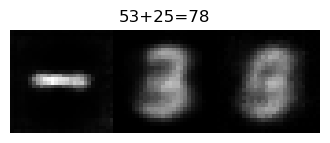

10-20


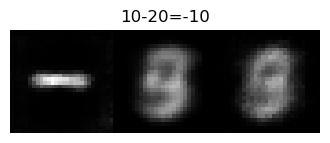

43+34


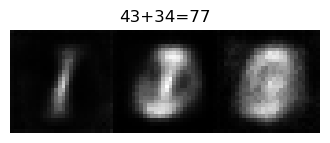

5+57 


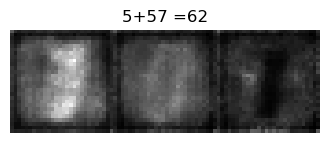

69+51


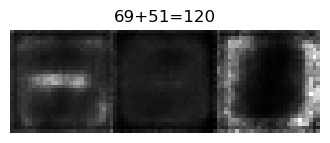

59-81


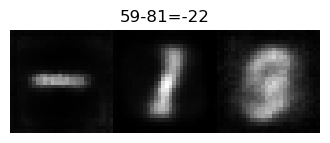

55+36


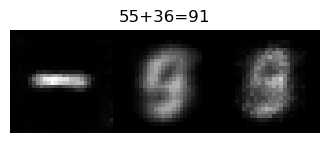

15+1 


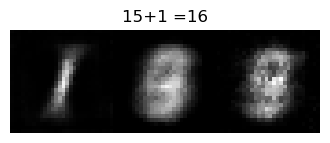

98-85


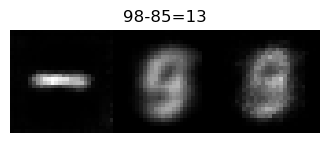

40-57


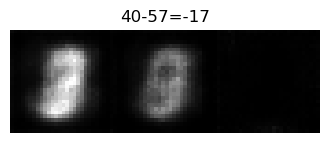

17-62


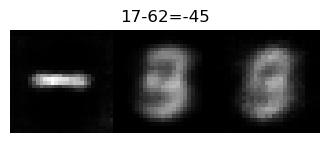

39-39


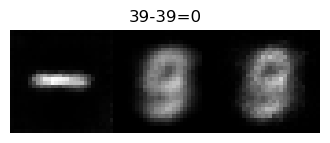

82-20


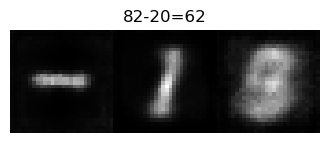

81+48


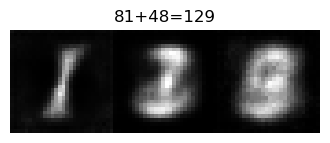

62+83


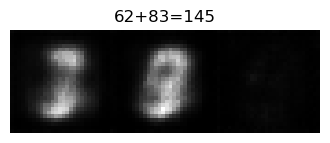

26+26


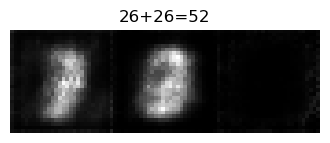

96-96


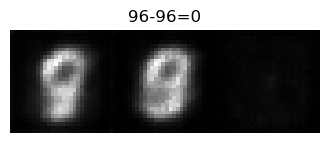

83+98


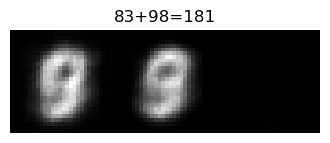

40+47


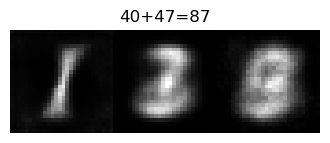

1+61 


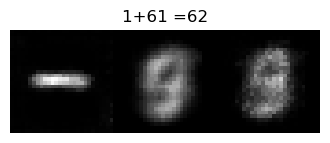

In [283]:

custom_objects = {
    "bce_ssim_loss": bce_ssim_loss,
    "ssim_metric": ssim_metric,
    # "mse_metric": mse_metric,
  }
# text2image =tf.keras.models.load_model(f'text2image2.keras', custom_objects=custom_objects)
gen_y = text2image.predict(X_val)

X_text_decoded=(decode_labels_from_integers(X_text_int_test))

for i in range(20):
    plt.figure(figsize=(4,2))
    plt.axis('off')
    print(X_text_decoded[i])
    plt.title(f'{X_text_decoded[i]}={eval(X_text_decoded[i])}')
    plt.imshow(np.hstack(gen_y[i]), cmap='gray')
    plt.show()

In [284]:
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    TimeDistributed, LSTM, InputLayer
)
from tensorflow.keras.models import Model, Sequential

train a separate supervised model for evaluating the generated images of your text-to-
image model

In [285]:
def build_sequence_evaluator(num_classes=13, sequence_length=3):
    cnn_extractor = cnn_extractor = Sequential([
        InputLayer(shape=(28, 28, 1)),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten()
    ], name="cnn_extractor")

    model = Sequential([
        InputLayer(shape=(sequence_length, 28, 28, 1)),
        TimeDistributed(cnn_extractor),
        LSTM(128, return_sequences=True),
        TimeDistributed(Dense(num_classes, activation='softmax'))
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    model.summary()
    return model
evaluator = build_sequence_evaluator(num_classes=len(unique_characters))

Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_70             │ (None, 3, 3136)        │        18,816 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_102 (LSTM)                 │ (None, 3, 128)         │     1,671,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_71             │ (None, 3, 13)          │         1,677 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,692,173 (6.46 MB)

 Trainable params: 1,692,173 (6.46 MB)

 Non-trainable params: 0 (0.00 B)

In [286]:
X_train, X_test, y_train, y_test = train_test_split(y_img, y_text_onehot, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

In [287]:
# evaluator.fit(
#     X_train, y_train,
#     epochs=100,
#     batch_size=64,
#     validation_data=(X_val, y_val),
#     callbacks=[early_stopper, lr_scheduler]
# )

In [288]:
# evaluator.save('evaluator.keras')

In [289]:
evaluator = tf.keras.models.load_model(f'evaluator.keras')
evaluator.evaluate(X_test,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9953 - loss: 0.0156


[0.0155565794557333, 0.995333194732666]

In [290]:
from sklearn.metrics import accuracy_score

text2image= tf.keras.models.load_model(f'text2image3.keras',custom_objects=custom_objects)
X_text_onehot_train, X_text_onehot_test, \
y_text_onehot_train, y_text_onehot_test, \
X_img_train, X_img_test = train_test_split(
    X_text_onehot,
    y_text_onehot,
    X_img,
    test_size=split,
    random_state=42
)
generated_images = text2image.predict(X_text_onehot_test)
generated_images_reshaped = generated_images.reshape(y_text_onehot_test.shape[0], 3, 28, 28, 1)

eval_predictions = evaluator.predict(generated_images_reshaped, batch_size=128)
true_labels = y_text_onehot_test

pred_flat = eval_predictions.reshape(-1, len(unique_characters))
true_flat = true_labels.reshape(-1, len(unique_characters))


pred_chars = np.argmax(pred_flat, axis=1)
true_chars = np.argmax(true_flat, axis=1)

char_accuracy = accuracy_score(true_chars, pred_chars)
print(f"Accuracy: {char_accuracy * 100:.2f}%")
pred_seqs = np.argmax(eval_predictions, axis=2) # shape: (num_samples, 3)
true_seqs = np.argmax(true_labels, axis=2)      # shape: (num_samples, 3)

correct_sequences = 0
for i in range(len(true_seqs)):
    # np.all checks if every character in the sequence is True
    if np.all(pred_seqs[i] == true_seqs[i]):
        correct_sequences += 1

full_answer_accuracy = (correct_sequences / len(true_seqs)) * 100
print(f"Full Accuracy: {full_answer_accuracy:.2f}%")

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 5, 13), dtype=float32). Expected shape (None, 5), but input has incompatible shape (32, 5, 13)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 5, 13), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>